# K-Nearest Neighbors on Aviation Wildlife Strikes

Use geographic and aircraft data to classify the risk level of a wildlife strike.

## 1. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import os

from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/AI Project'
DATA = os.path.join(BASE, 'datasets')
RESULTS = os.path.join(BASE, 'results')
os.makedirs(RESULTS, exist_ok=True)

Mounted at /content/drive


## 2. Load and Preprocess Data

In [2]:
df = pd.read_csv(os.path.join(DATA, 'wildlife_strikes.csv'))
print(f'Loaded {len(df)} wildlife strike records')

EFFECT_MAP = {
    'None': 0, 'Other': 1,
    'Precautionary Landing': 2,
    'Aborted Take-off': 3,
    'Engine Shut Down': 4
}
df['effect'] = df['effect'].fillna('None').map(EFFECT_MAP)
df = df.dropna(subset=['effect'])

species_counts = df['species'].value_counts()
rare = species_counts[species_counts < 50].index
df['species_clean'] = df['species'].fillna('UNKNOWN').replace(rare, 'OTHER')

for col in ['phase_of_flt', 'time_of_day', 'sky']:
    df[col] = df[col].fillna('Unknown')

for col in ['height', 'speed', 'ac_mass', 'num_engs']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in ['phase_of_flt', 'time_of_day', 'sky', 'species_clean']:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col])

feature_cols = ['height', 'speed', 'ac_mass', 'num_engs',
                'phase_of_flt_enc', 'time_of_day_enc', 'sky_enc', 'species_clean_enc']
X = df[feature_cols].values.astype(np.float64)
y = df['effect'].values.astype(np.int64)

print(f'Features: {feature_cols}')
print(f'Effect distribution:')
print(df['effect'].map({v:k for k,v in EFFECT_MAP.items()}).value_counts().sort_index())
print(f'X shape: {X.shape}')

Loaded 19302 wildlife strike records
Features: ['height', 'speed', 'ac_mass', 'num_engs', 'phase_of_flt_enc', 'time_of_day_enc', 'sky_enc', 'species_clean_enc']
Effect distribution:
effect
Aborted Take-off           544
Engine Shut Down           116
None                     17329
Other                      348
Precautionary Landing      965
Name: count, dtype: int64
X shape: (19302, 8)


## 3. Find Best k Value

Train: 15441, Test: 3861
Best k = 8 with test accuracy = 0.8977


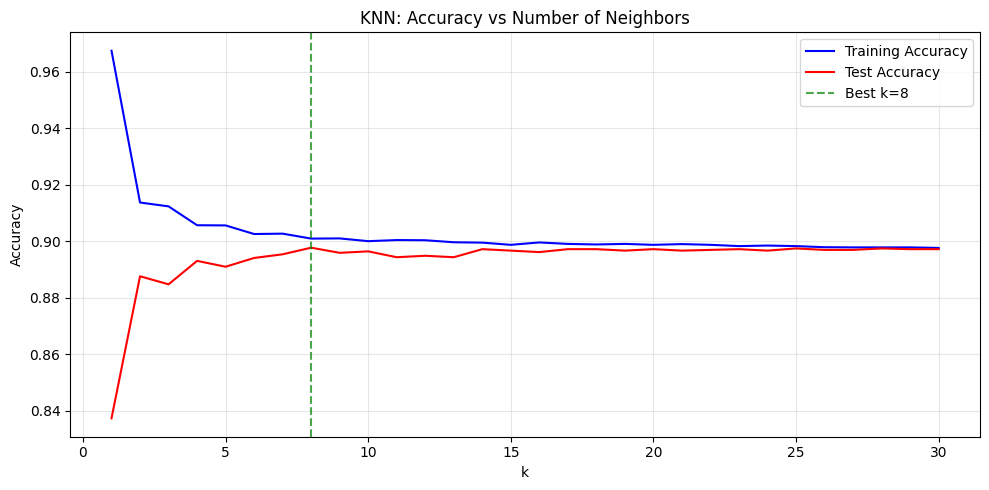

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

train_acc, test_acc = [], []
K_range = range(1, 31)
for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

best_k = K_range[list(test_acc).index(max(test_acc))]
print(f'Best k = {best_k} with test accuracy = {max(test_acc):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, train_acc, 'b-', label='Training Accuracy')
ax.plot(K_range, test_acc, 'r-', label='Test Accuracy')
ax.axvline(best_k, color='g', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax.set_title('KNN: Accuracy vs Number of Neighbors')
ax.set_xlabel('k'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'wildlife_knn_accuracy.png'), dpi=100)
plt.show()

## 4. Train and Evaluate Final Model

In [4]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

cv_scores = cross_val_score(knn, X_scaled, y, cv=5)
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

effect_names = ['None', 'Other', 'Precautionary Landing', 'Aborted Take-off', 'Engine Shut Down']
y_pred = knn.predict(X_test)
print(f'\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=effect_names, zero_division=0))

5-Fold CV Accuracy: 0.8954 (+/- 0.0012)

Test Accuracy: 0.8977
                       precision    recall  f1-score   support

                 None       0.90      1.00      0.95      3466
                Other       1.00      0.01      0.03        70
Precautionary Landing       0.20      0.01      0.02       193
     Aborted Take-off       0.47      0.07      0.13       109
     Engine Shut Down       0.00      0.00      0.00        23

             accuracy                           0.90      3861
            macro avg       0.51      0.22      0.22      3861
         weighted avg       0.85      0.90      0.85      3861



## 5. Confusion Matrix

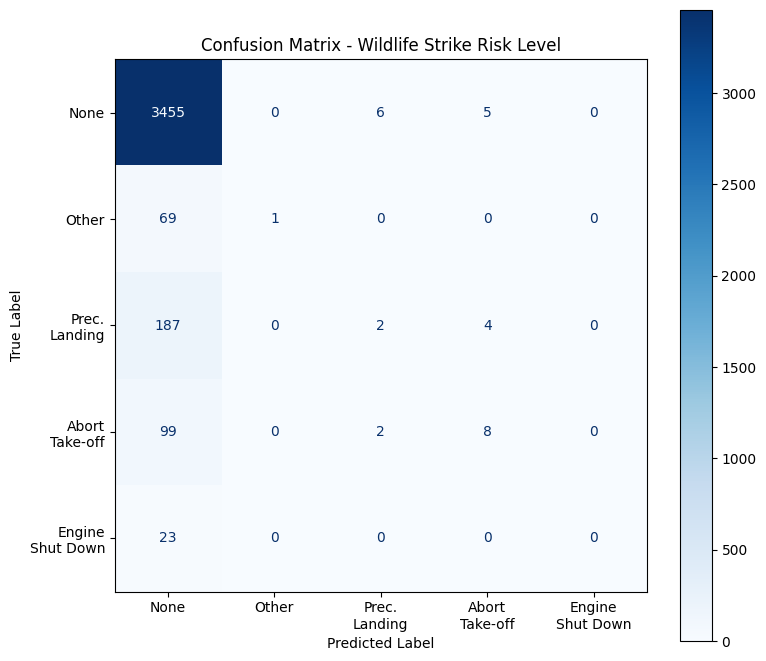

In [5]:
short_names = ['None', 'Other', 'Prec.\nLanding', 'Abort\nTake-off', 'Engine\nShut Down']
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=0)
ax.set_title('Confusion Matrix - Wildlife Strike Risk Level')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'wildlife_confusion_matrix.png'), dpi=120)
plt.show()

## 6. Summary

- **89.8% accuracy** — but heavily imbalanced (89.8% of reports are 'None')
- Model is good at identifying **non-damaging strikes** (recall = 1.00)
- Minority classes (Engine Shut Down, Aborted Take-off) need more data
- Future work: SMOTE oversampling or class weights